In [ ]:
import os
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use('bmh')

In [20]:
ruta = "/Users/andresitoortiz/Library/Mobile Documents/com~apple~CloudDocs/Pregrado_Fisica/2025-2/Lab_intermedio/Franck-Hertz/FranckHertz/Actividad_3"
data = {}
for archivo in glob.glob(os.path.join(ruta, "*.csv")):
    nombre = os.path.basename(archivo)
    df = pd.read_csv(archivo, delimiter=';')
    df = df.replace(',', '.', regex=True)
    data[nombre] = df

print("Archivos cargados:", list(data.keys()))
voltajes = [1,1.5,2]
print(data.values())

Archivos cargados: ['3_U2_1V.csv', '3_U2_13V.csv', '3_U2_2V.csv']
dict_values([     Voltage U1 Corriente IA
0          0.02         0.34
1          0.04         0.31
2          0.07         0.32
3          0.09          0.3
4          0.12         0.34
...         ...          ...
2104       51.4           50
2105      51.42           50
2106      51.45           50
2107      51.47           50
2108       51.5           50

[2109 rows x 2 columns],      Voltage U1 Corriente IA
0          0.02         0.25
1          0.04          0.3
2          0.07         0.36
3          0.09         0.37
4          0.12         0.41
...         ...          ...
2452       59.9           50
2453      59.92           50
2454      59.95           50
2455      59.97           50
2456      59.99           50

[2457 rows x 2 columns],      Voltage U1 Corriente IA
0          U1/V        IA/nA
1           NaN          NaN
2          0.02         0.55
3          0.04         0.54
4          0.07         0.52

In [3]:
solarized_colors = [
    "#268BD2",  # azul
    "#2AA198",  # verde-azulado
    "#859900",  # verde amarillento
    "#CB4B16",  # naranja profundo
    "#DC322F",  # rojo
    "#B58900",  # amarillo tostado
    "#6C71C4",  # púrpura
    "#586E75"   # gris azulado
]

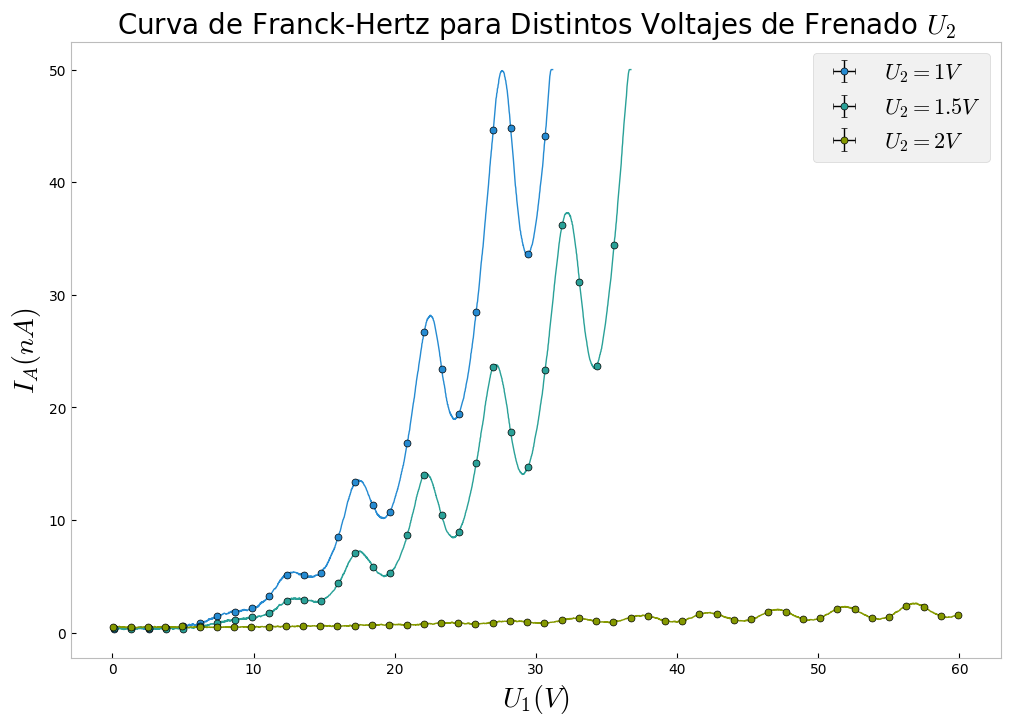

In [22]:
fig,axes = plt.subplots(1,figsize=(12,8))
axes.set_facecolor("#FFFFFF")
i=0

for df in data.values():
    dff = df[2:-1].astype(float)
    x = dff["Voltage U1"]
    y = dff["Corriente IA"]
    
    if i==0: #1V
        axes.errorbar(x[2:1275:50], y[2:1275:50],
            xerr=0.01, yerr=0.01,
            fmt='o',color = solarized_colors[i] , markersize = 5, markeredgewidth = 0.5, markeredgecolor = 'k',
            capsize = 2, elinewidth = 1, ecolor = 'k',
            label=fr'$U_2 = {voltajes[i]} V$')
        axes.plot(x[2:1275], y[2:1275], color = solarized_colors[i], linewidth = 1)
           
        
    elif i==1: #1.3V
        
        axes.errorbar(x[2:1502:50], y[2:1502:50],
            xerr=0.01, yerr=0.01,
            fmt='o',color = solarized_colors[i] , markersize = 5, markeredgewidth = 0.5, markeredgecolor = 'k',
            capsize = 2, elinewidth = 1, ecolor = 'k',
            label=fr'$U_2 = {voltajes[i]} V$')
        axes.plot(x[2:1502], y[2:1502], color = solarized_colors[i], linewidth = 1)
    
    
    elif i==2: #2V
        axes.errorbar(x[2:-1:50], y[2:-1:50],
            xerr=0.01, yerr=0.01,
            fmt='o',color = solarized_colors[i] , markersize = 5, markeredgewidth = 0.5, markeredgecolor = 'k',
            capsize = 2, elinewidth = 1, ecolor = 'k',
            label=fr'$U_2 = {voltajes[i]} V$')
        axes.plot(x[2:-1], y[2:-1], color = solarized_colors[i], linewidth = 1)
        
    i+=1
axes.set_title("Curva de Franck-Hertz para Distintos Voltajes de Frenado " + fr"$U_2$", fontsize=20)
axes.set_xlabel(fr"$U_1 (V)$", fontsize=20)
axes.set_ylabel(fr"$I_A (nA)$", fontsize=20)
plt.legend(fontsize=16)
plt.grid(False)   
plt.savefig("Curvas_Franck_Hertz_Voltajes_Frenado.png", dpi=300) 
plt.show()